VWAP 偏离 × 日内趋势强度 联合因子 (VWAP Deviation × Trend Strength)

将 VWAP 偏离（微观结构 dislocation）与日内趋势强度（行为过度反应）
这两个正交信号结合，实现"双重确认才给强信号"。

核心逻辑：
  VWAP 偏离（close/VWAP - 1）回答"价格是否偏离了公平值"——
  来自市场微观结构理论，是机构执行算法的自然锚点。

  日内趋势强度（(close-open)/(high-low)）回答"日内走势是否极端"——
  来自行为金融理论，捕捉散户追涨杀跌的过度反应。

  当两者同向时（如 close >> VWAP 且全天光头阳线）→ 双重过度 →
  最强的反转信号。当两者反向或一方中性时 → 信号减弱。

因子构造：
  1. DAI SQL：日频 VWAP + OHLCV
  2. pandas：6 项增强
     - 成交量验证：放量偏离 = 力竭信号
     - 趋势强度交互：同向时加倍确认（核心增强）
     - 偏离日间变化：今日偏离 vs 昨日偏离的"意外"程度
     - 隔夜跳空交互：跳空+日内同向 = 多重过度
     - 窄幅波动降权：振幅过小 → 信号噪声大
     - 微小偏离过滤：VWAP 偏离 < 0.2% → 噪声主导
  3. 取相反数（正偏离=超买→预期下跌，原始方向为负向）

预期方向：收盘越高于 VWAP + 趋势越极端 → 过度越严重 → 未来收益越低 → 取反后转为正向。

与现有因子的区别：
  - VWAP raw/20d 版：只用 VWAP 偏离，忽略了日内走势形态
  - 日内趋势 raw/enhanced 版：只看蜡烛形态，忽略了执行成本锚点
  - 本因子：两个正交维度交互确认，只在双重确认时给强信号

参考文献：
  Berkowitz, S. A., Logue, D. E., & Noser, E. A. (1988, JFQA).
    "The total cost of transactions on the NYSE"
  Lo, A. W., & MacKinlay, A. C. (1990, RFS).
    "When are contrarian profits due to stock market overreaction?"
  Humphery-Jenner, M. L. (2011, Working Paper).
    "Optimal VWAP trading and the cross-section of stock returns"

In [1]:
def main(datasources, start_date, end_date):
    """计算 VWAP × 趋势强度联合因子。

    Parameters
    ----------
    datasources : dict
        平台注入的数据源映射，逻辑名 "bar1m" → 物理表名
    start_date : str
        评测起始日期
    end_date : str
        评测结束日期

    Returns
    -------
    pd.DataFrame
        三列：date, instrument, factor（值越大预期收益越高）
    """
    import pandas as pd
    import numpy as np
    import dai

    bar1m_table = datasources["bar1m"]

    # ============================================================
    # 阶段 A：时间窗口设定
    #
    # 回溯需求（60 个自然日覆盖所有）：
    #   - 20 日均量：~30 个自然日
    #   - 昨日 VWAP 偏离（dev_change）：1 个交易日
    #   - 昨日收盘（overnight_gap）：1 个交易日
    # ============================================================
    lookback_start_dt = pd.to_datetime(start_date) - pd.Timedelta(days=60)
    lookback_start = lookback_start_dt.strftime("%Y-%m-%d")
    # CC: +1 天避免 timestamp_ns 过滤截断最后一天
    query_end_dt = pd.to_datetime(end_date) + pd.Timedelta(days=1)
    query_end = query_end_dt.strftime("%Y-%m-%d")

    # ============================================================
    # 阶段 B：DAI SQL — 分钟 bar → 日频 VWAP + OHLCV
    #
    # VWAP = Σ(amount) / Σ(volume)，逐分钟累加后相除。
    # 同时取首分钟 open、末分钟 close、全天 high/low/volume，
    # 用于计算趋势强度和各项增强。
    # ============================================================
    sql = f"""
    WITH minute_ranked AS (
        SELECT
            date::DATE AS trade_date,
            instrument,
            date AS ts,
            volume,
            amount,
            open,
            high,
            low,
            close,
            ROW_NUMBER() OVER (
                PARTITION BY instrument, date::DATE ORDER BY date ASC
            ) AS rn_asc,
            ROW_NUMBER() OVER (
                PARTITION BY instrument, date::DATE ORDER BY date DESC
            ) AS rn_desc
        FROM {bar1m_table}
        WHERE volume > 0 AND close > 0 AND open > 0 AND high > 0 AND low > 0
    )
    SELECT
        trade_date AS date,
        instrument,
        -- CC: VWAP = 全天总成交额 / 全天总成交量（机构执行成本基准）
        SUM(amount) / NULLIF(SUM(volume), 0) AS vwap,
        -- CC: 首分钟开盘价（用于趋势强度 + 隔夜跳空）
        MAX(CASE WHEN rn_asc = 1 THEN open END) AS daily_open,
        -- CC: 末分钟收盘价（用于 VWAP 偏离 + 趋势强度）
        MAX(CASE WHEN rn_desc = 1 THEN close END) AS daily_close,
        -- CC: 全天最高/最低价（用于趋势强度 + 窄幅过滤）
        MAX(high) AS daily_high,
        MIN(low) AS daily_low,
        -- CC: 日总成交量（成交量验证）
        SUM(volume) AS daily_volume,
        -- CC: 日总成交额（质量控制）
        SUM(amount) AS daily_amount,
        COUNT(*) AS n_minutes
    FROM minute_ranked
    GROUP BY trade_date, instrument
    """

    daily_df = dai.query(
        sql,
        filters={'date': [lookback_start, query_end]},
    ).df()

    # ============================================================
    # 阶段 C：数据清洗
    # ============================================================
    daily_df['date'] = pd.to_datetime(daily_df['date'])

    # CC: 过滤低活跃度交易日
    daily_df = daily_df[daily_df['n_minutes'] >= 120]
    daily_df = daily_df[daily_df['daily_amount'] > 0]
    daily_df = daily_df[daily_df['daily_volume'] > 0]

    # CC: DAI 返回的数值列显式转 float
    float_cols = ['vwap', 'daily_open', 'daily_close', 'daily_high',
                  'daily_low', 'daily_volume', 'daily_amount']
    for col in float_cols:
        if col in daily_df.columns:
            daily_df[col] = daily_df[col].astype(float)

    daily_df = daily_df.dropna(subset=['vwap', 'daily_open', 'daily_close',
                                        'daily_high', 'daily_low'])

    # CC: 排序保证 shift/rolling 操作正确
    daily_df = daily_df.sort_values(['instrument', 'date']).reset_index(drop=True)

    # ============================================================
    # 阶段 D：双信号 + 6 项增强
    # ============================================================

    # ----------------------------------------------------------
    # D0：两个基础信号
    #
    # 信号 A — VWAP 偏离（主信号，微观结构 dislocation）
    #   正值：close > VWAP → 收盘被推离公平价 → 超买 → 应反转下跌
    #   负值：close < VWAP → 收盘被压低 → 超卖 → 应反弹
    #
    # 信号 B — 日内趋势强度（辅助信号，行为过度反应）
    #   ≈+1：光头阳线（全天单边涨）
    #   ≈-1：光脚阴线（全天单边跌）
    #   ≈ 0：十字星（多空均衡）
    # ----------------------------------------------------------
    daily_df = daily_df[daily_df['daily_high'] > daily_df['daily_low']].copy()

    # CC: 信号 A — VWAP 偏离
    daily_df['vwap_dev'] = daily_df['daily_close'] / daily_df['vwap'] - 1.0
    daily_df['vwap_dev'] = daily_df['vwap_dev'].clip(-0.15, 0.15)

    # CC: 信号 B — 日内趋势强度
    daily_df['trend_strength'] = (
        (daily_df['daily_close'] - daily_df['daily_open'])
        / (daily_df['daily_high'] - daily_df['daily_low'])
    )
    daily_df['trend_strength'] = daily_df['trend_strength'].clip(-1.5, 1.5)

    # CC: 缓存符号列，多处复用
    dev_sign = np.sign(daily_df['vwap_dev'])
    ts_sign = np.sign(daily_df['trend_strength'])

    # ----------------------------------------------------------
    # 增强 #1：成交量验证（Volume Climax）
    #
    # 直觉：偏离 VWAP 2% 且放量 → 大量交易者在偏离公平价的位置成交
    #       → 更多人的成本远离当前价 → 回归力量更强
    #       缩量的偏离 → 可能是尾盘少量交易造成的 → 信号弱
    # ----------------------------------------------------------
    daily_df['vol_20d_avg'] = daily_df.groupby('instrument')['daily_volume'].transform(
        lambda x: x.rolling(20, min_periods=5).mean()
    )
    daily_df['vol_ratio'] = daily_df['daily_volume'] / daily_df['vol_20d_avg']
    daily_df['vol_ratio'] = daily_df['vol_ratio'].clip(0.3, 3.0)

    # ----------------------------------------------------------
    # 增强 #2：趋势强度交互（CORE — 本因子的核心增强）
    #
    # 直觉：VWAP 偏离和趋势强度的组合有四种情形：
    #
    #   VWAP偏离  趋势强度  含义                          信号强度
    #   ────────  ────────  ──────────────────────────   ────────
    #   +2%       +0.9      光头阳线 + 远超公平价         最强反转
    #                       尾盘追涨情绪 + 执行成本偏离
    #                       → 买方力量已耗尽
    #
    #   +2%       -0.3      收盘高于 VWAP，但日内走弱      中等反转
    #                       可能只是开盘跳空后横盘
    #                       → VWAP 偏离有效，但无情绪极端
    #
    #   +2%       -0.8      收盘高于 VWAP，但日内大跌      弱反转/可疑
    #                       跳空高开后大幅回落但仍高于 VWAP
    #                       → 已在日内部分修正，剩余空间小
    #
    #   ≈0%       +0.9      光头阳线但价格未偏离公平价      弱信号
    #                       趋势虽极端，但始终在公平价附近
    #                       → VWAP 不确认，仅是日内噪声
    #
    # 实现：同向时 amplify = 1 + |trend_strength|（最大 ~2.5x）
    #       反向或中性 → 保持 1.0（不放大，信任 VWAP 基础信号）
    # ----------------------------------------------------------
    daily_df['ts_same_dir'] = (
        (dev_sign == ts_sign) &
        (daily_df['trend_strength'].notna()) &
        (daily_df['vwap_dev'].notna())
    ).astype(float)

    # CC: 同向时趋势越极端 → 确认越强
    #     |trend_strength|=0.3 → amp=1.3；|trend_strength|=0.9 → amp=1.9
    daily_df['trend_amp'] = (
        1.0 + np.abs(daily_df['trend_strength']) * daily_df['ts_same_dir']
    )

    # ----------------------------------------------------------
    # 增强 #3：偏离日间变化（Surprise / Deviation Change）
    #
    # 直觉：VWAP 偏离的"意外"程度比绝对水平更重要。
    #
    #   昨天 -1%，今天 +2% → +3% 摆动 → 剧烈 reversal
    #     （从超卖跳到超买，参与者结构发生剧变）
    #
    #   昨天 +2%，今天 +2% → 无变化 → 持续的超买
    #     （可能是有原因的持续溢价，不一定是 dislocation）
    #
    # surprise_amp = 1 + |dev_change| * 3
    #   3% 摆动 → amp=1.09；5% 摆动 → amp=1.15
    # ----------------------------------------------------------
    daily_df['vwap_dev_lag1'] = daily_df.groupby('instrument')['vwap_dev'].shift(1)
    daily_df['dev_change'] = daily_df['vwap_dev'] - daily_df['vwap_dev_lag1']
    daily_df['surprise_amp'] = 1.0 + np.abs(daily_df['dev_change'].fillna(0)) * 3.0

    # ----------------------------------------------------------
    # 增强 #4：隔夜跳空交互（Overnight Gap Interaction）
    #
    # 直觉：跳空 + VWAP 偏离同向 = 隔夜情绪 + 盘中执行成本双偏离
    #       跳空高开 5% + close 高于 VWAP 2% → 多重过度 → 最强反转
    #       跳空高开 5% + close 低于 VWAP -1% → 盘中已消化 → 信号中立
    #
    # 注意：这里用 daily_open（首分钟开盘）和 prev_close 计算跳空，
    #       与趋势强度增强版相同逻辑，但乘到 VWAP 偏离上。
    # ----------------------------------------------------------
    daily_df['prev_close'] = daily_df.groupby('instrument')['daily_close'].shift(1)
    daily_df['overnight_gap'] = (
        (daily_df['daily_open'] - daily_df['prev_close'])
        / daily_df['prev_close']
    )
    daily_df['overnight_gap'] = daily_df['overnight_gap'].clip(-0.15, 0.15)

    daily_df['gap_same_dir'] = (
        (np.sign(daily_df['overnight_gap']) == dev_sign) &
        (daily_df['overnight_gap'].notna())
    ).astype(float)
    # CC: 跳空同向时 amplify，权重系数 1.5（比趋势交互的 1.0 稍小，
    #     因为 VWAP 偏离本身已部分包含了跳空的影响）
    daily_df['gap_amp'] = (
        1.0 + np.abs(daily_df['overnight_gap'].fillna(0)) * daily_df['gap_same_dir'] * 1.5
    )

    # ----------------------------------------------------------
    # 增强 #5：窄幅波动降权（Narrow Range Filter）
    #
    # 与趋势强度增强版相同逻辑：
    #   振幅 < 0.5% → (close-open)/(high-low) 噪声大
    #   虽然 VWAP 偏离不受此影响，但趋势强度交互项受影响
    # ----------------------------------------------------------
    daily_df['range_pct'] = (
        (daily_df['daily_high'] - daily_df['daily_low'])
        / daily_df['daily_close']
    )
    daily_df['range_weight'] = np.minimum(daily_df['range_pct'] / 0.005, 1.0)

    # ----------------------------------------------------------
    # 增强 #6：微小偏离过滤（Tiny Deviation Filter）
    #
    # 直觉：VWAP 偏离 < 0.2%（2bp）时，偏离量在买卖价差范围内，
    #       实质上是"零偏离"——信号主要由噪声主导。
    #
    # ramp = min(|dev| / 0.002, 1.0)
    #   |dev|=0.05% → weight=0.25（几乎忽略）
    #   |dev|=0.10% → weight=0.50
    #   |dev|=0.20% → weight=1.00（完全信任）
    #
    # 与窄幅过滤的区别：窄幅过滤看价格振幅，这个看 VWAP 偏离幅度。
    # 一只股票可以振幅很大（range_pct=3%）但 VWAP 偏离很小（股价始终
    # 围绕 VWAP 上下波动）——这两种情况各自独立。
    # ----------------------------------------------------------
    daily_df['tiny_dev_weight'] = np.minimum(
        np.abs(daily_df['vwap_dev']) / 0.002, 1.0
    )

    # ============================================================
    # 阶段 E：信号合成
    #
    # 增强版 VWAP 因子 = vwap_dev × 所有乘子
    #
    # 乘子分类：
    #   Amplifier（≥1.0，放大信号）：
    #     vol_ratio        — 量价验证：[0.3, 3.0]
    #     trend_amp        — 趋势确认：[1.0, ~2.5]  ← 核心增强
    #     surprise_amp     — 偏离变化：[1.0, ~1.5]
    #     gap_amp          — 跳空交互：[1.0, ~1.2]
    #
    #   Dampener（0~1.0，压制信号）：
    #     range_weight     — 窄幅降权：(0, 1.0]
    #     tiny_dev_weight  — 微小偏离：(0, 1.0]
    #
    # 对比 VWAP raw 版：factor = -vwap_dev × vol_ratio × trend_amp
    #                    × surprise_amp × gap_amp × range_weight × tiny_dev_weight
    #       VWAP raw 版：factor = -vwap_dev
    # ============================================================
    daily_df['factor'] = (
        daily_df['vwap_dev']           # 基础信号：[-0.15, 0.15]
        * daily_df['vol_ratio']        # 量价验证：[0.3, 3.0]
        * daily_df['trend_amp']        # 趋势确认：[1.0, ~2.5]
        * daily_df['surprise_amp']     # 偏离变化：[1.0, ~1.5]
        * daily_df['gap_amp']          # 跳空交互：[1.0, ~1.2]
        * daily_df['range_weight']     # 窄幅降权：(0, 1.0]
        * daily_df['tiny_dev_weight']  # 微小偏离：(0, 1.0]
    )

    # CC: 钳制——VWAP 偏离基础值较小（±15%），乘子后典型范围 ±0.3，
    #     极端可达 ±2.0，钳制到 [-1.0, 1.0] 覆盖绝大部分情形
    daily_df['factor'] = daily_df['factor'].clip(-1.0, 1.0)

    # ============================================================
    # 阶段 F：截取评测区间 + 股票池对齐
    # ============================================================
    mask = (daily_df['date'] >= pd.to_datetime(start_date)) & \
           (daily_df['date'] <= pd.to_datetime(end_date))
    result = daily_df[mask][['date', 'instrument', 'factor']].copy()

    # CC: 股票池 left join——消除幸存者偏差
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])

    result = pd.merge(stk_pool, result, how='left', on=['date', 'instrument'])
    result = result.replace([np.inf, -np.inf], np.nan)

    # CC: 取相反数——原始 vwap_dev 越大（超买）→ 预期收益越低（负向因子）
    result['factor'] = -result['factor']

    result = result[['date', 'instrument', 'factor']]
    return result



[2026-08-05 15:01:42] [info     ] 计算 VWAP × 趋势强度联合因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 15:04:57] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 15:04:57] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 15:05:01] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 15:05:01] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 15:05:01] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 15:05:01] [info     ] ========== 数据检查 ==========
[2026-08-05 15:05:01] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr

时段,IC
2024-01-15~2024-02-08,0.0079
2024-09-24~2024-10-08,0.0687

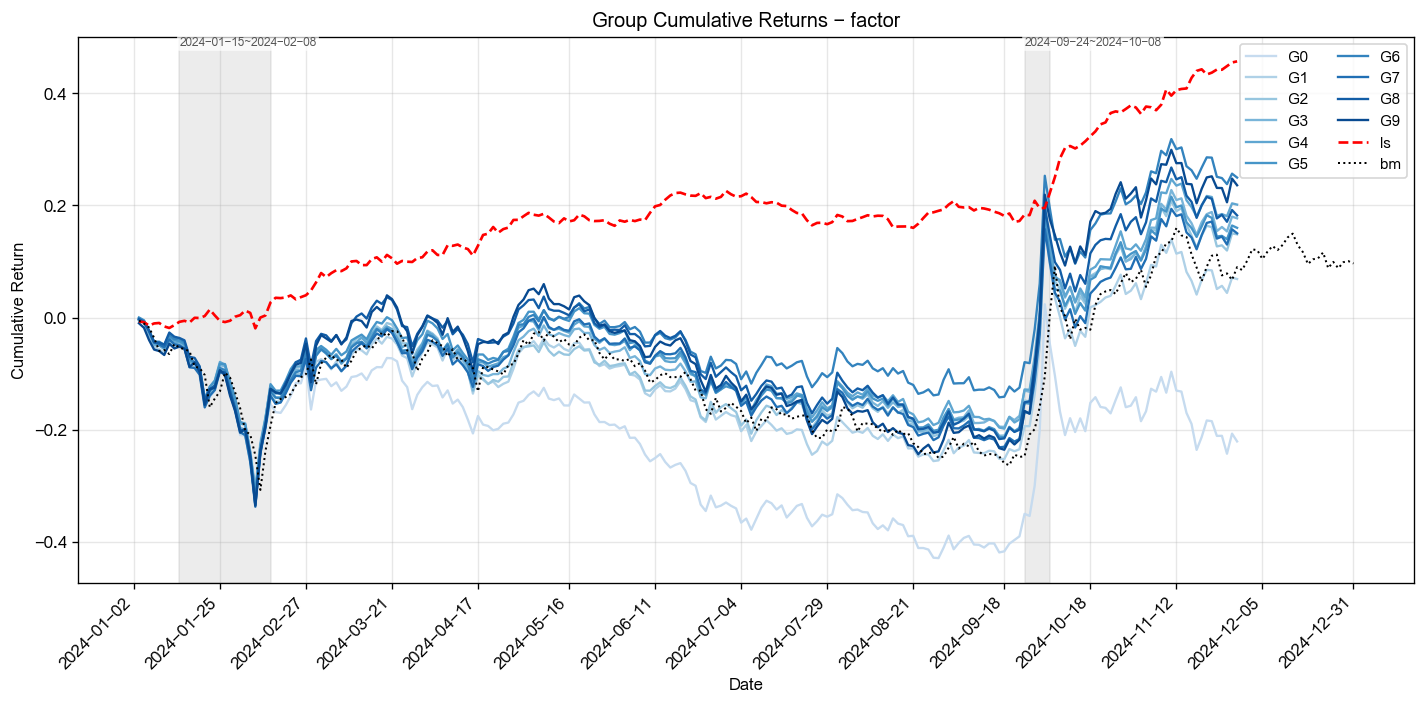
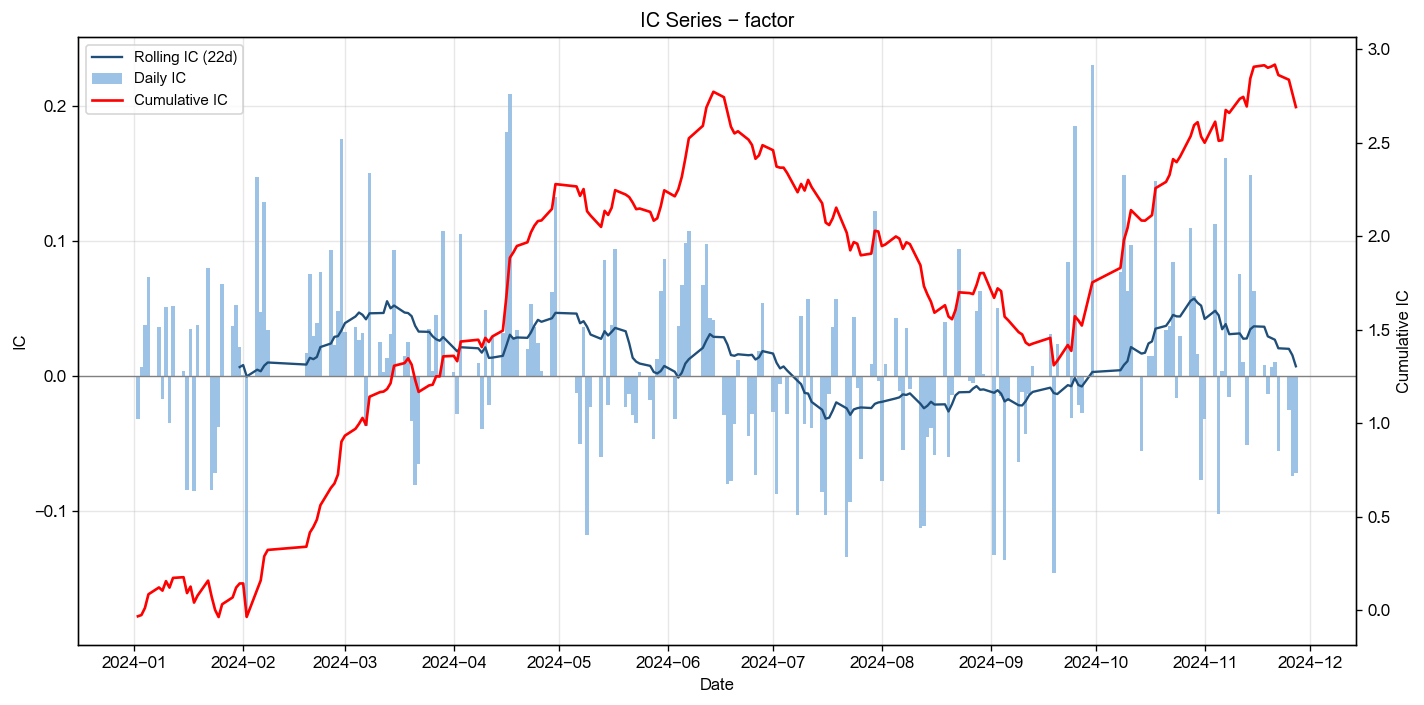
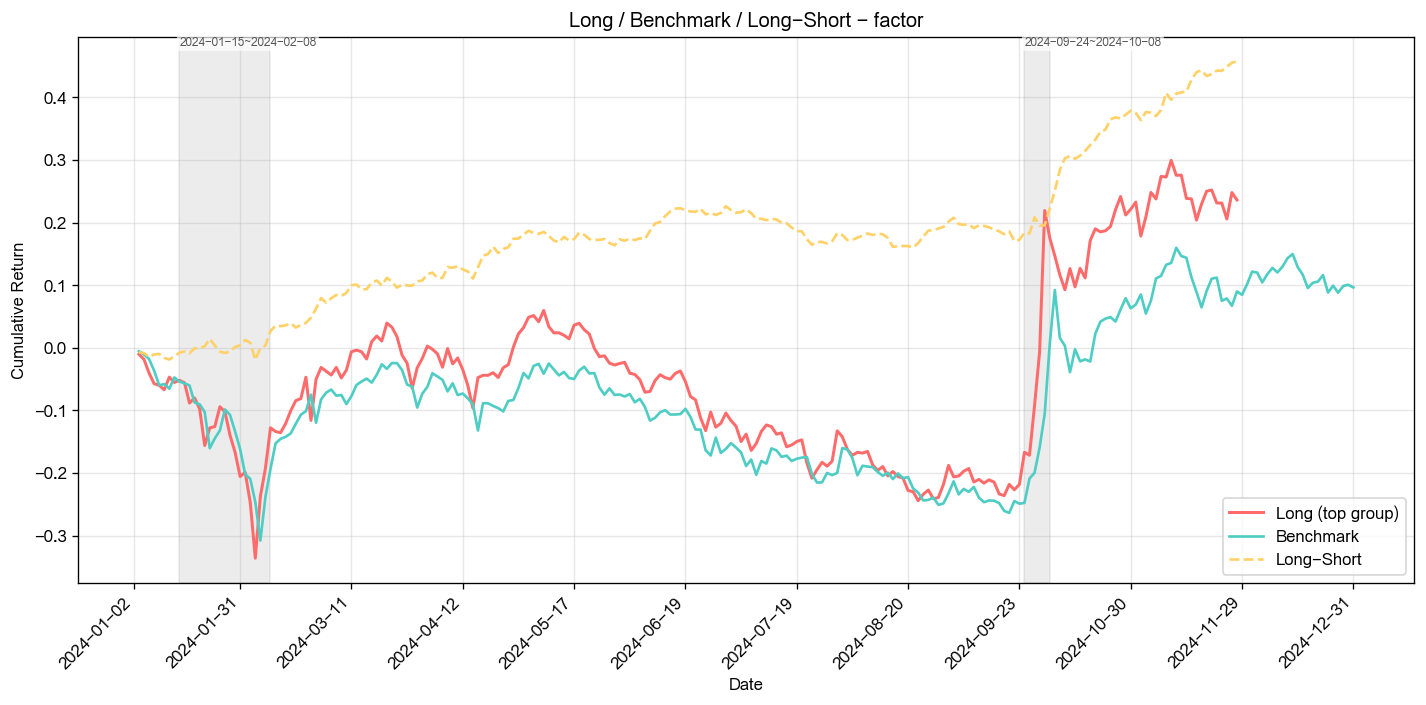
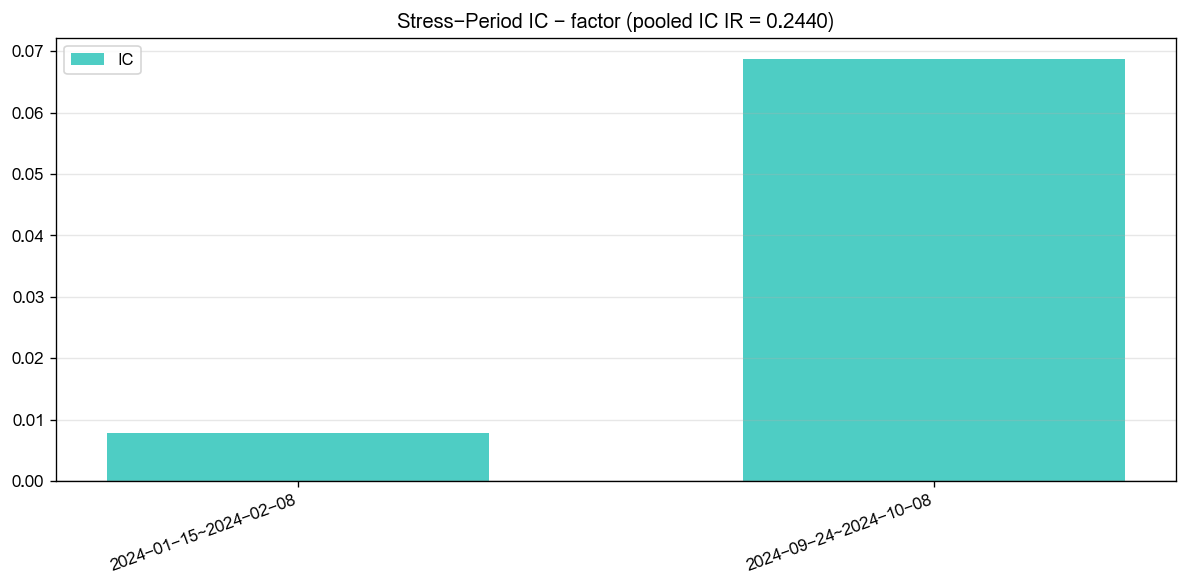
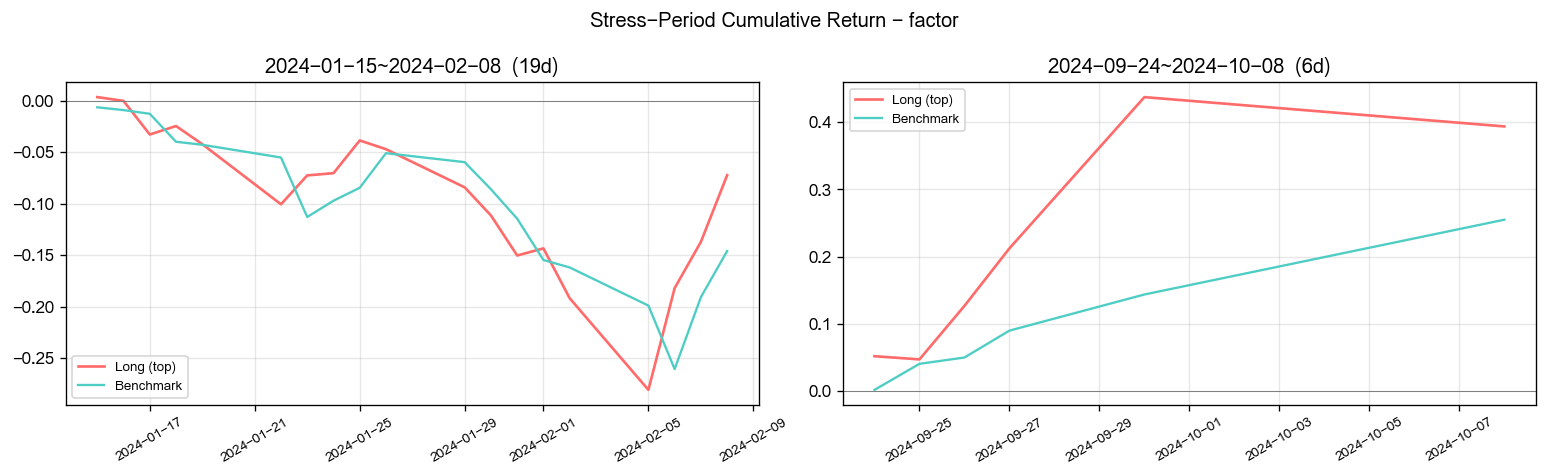

[2026-08-05 15:06:15] [info     ] ========== 因子池回归 ==========
[2026-08-05 15:06:15] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 15:06:16] [info     ] 获取收益率数据, 耗时: 0.7947 秒
[2026-08-05 15:06:16] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.5526 秒
[2026-08-05 15:06:16] [info     ] 统计 回归结果, 耗时: 0.1029 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,2.0320,0.0429,0.0211,1.0000
2,factor,1.8763,0.0316,0.0168,1.0000
3,cci_14,1.8570,0.0346,0.0186,1.0000
4,amount,1.8303,0.0194,0.0106,1.0000
5,netflow_amount_rate_main,1.5457,0.0100,0.0065,1.0000
6,gross_profit_rate_ttm,1.5379,0.0068,0.0044,1.0000
7,netflow_amount_main,1.4863,0.0238,0.0160,1.0000
8,net_profit_rate_ttm,1.4366,0.0040,0.0028,0.8000
9,bias_20,1.4235,0.0289,0.0203,0.9000
10,pb,1.3968,0.0098,0.0070,0.9000

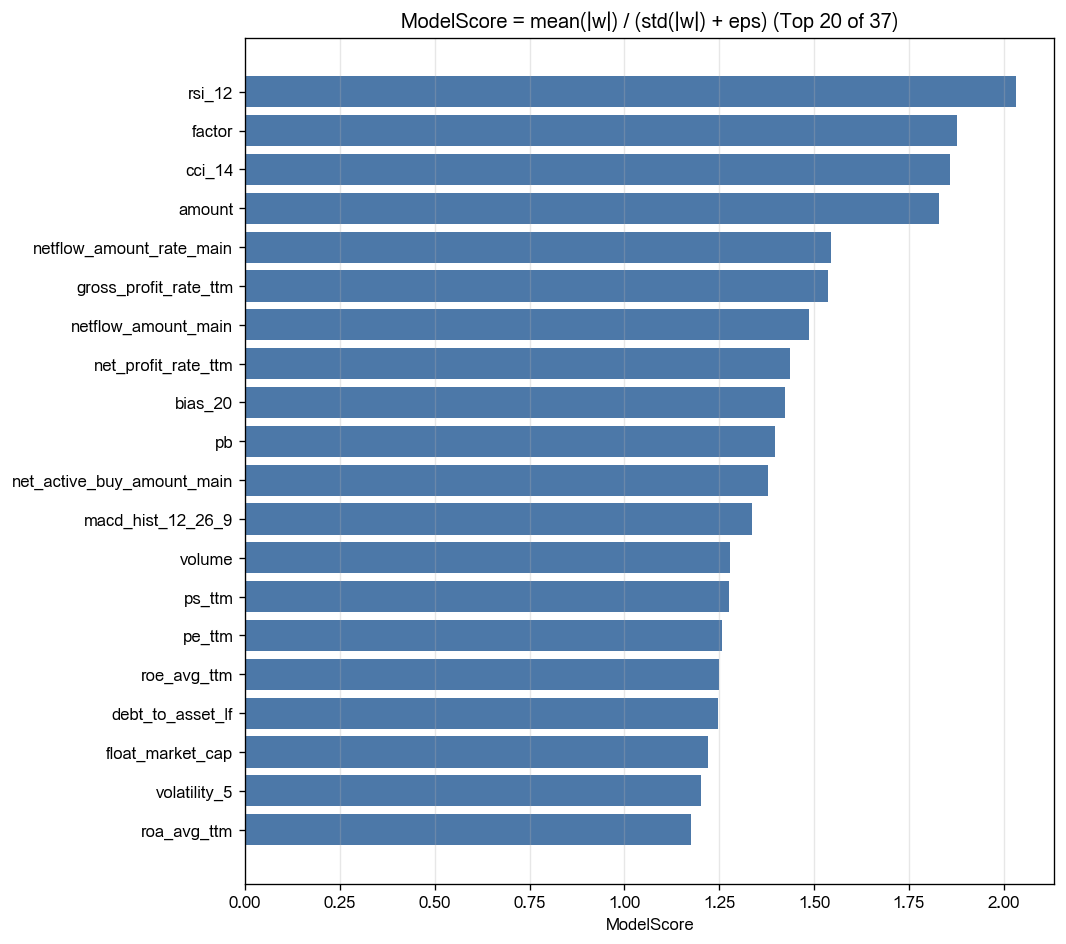
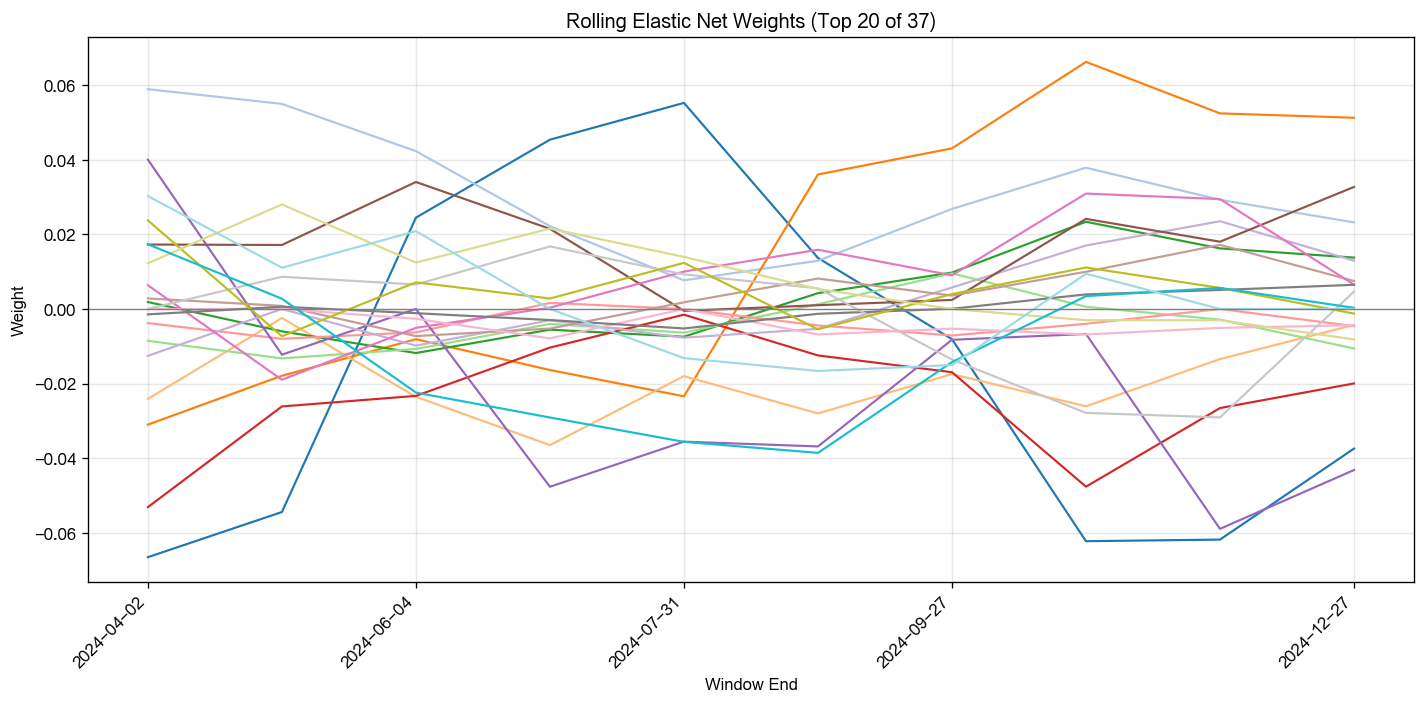
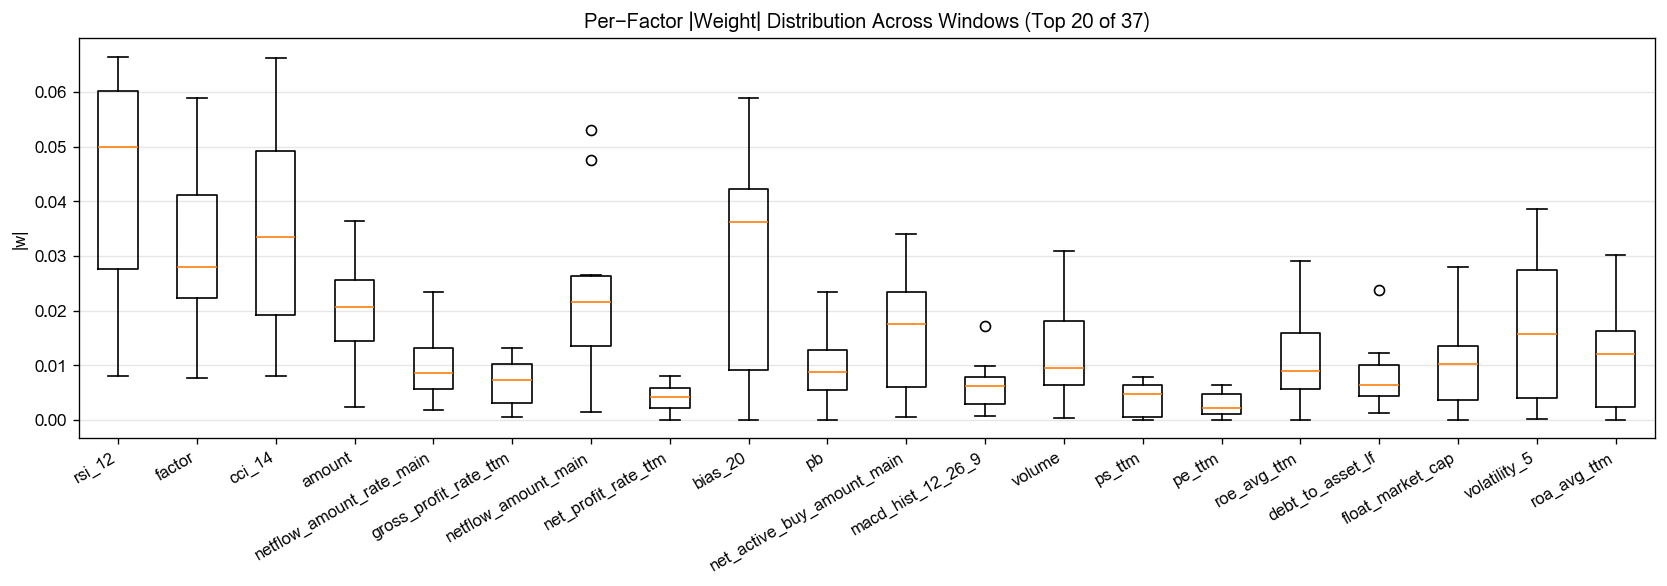
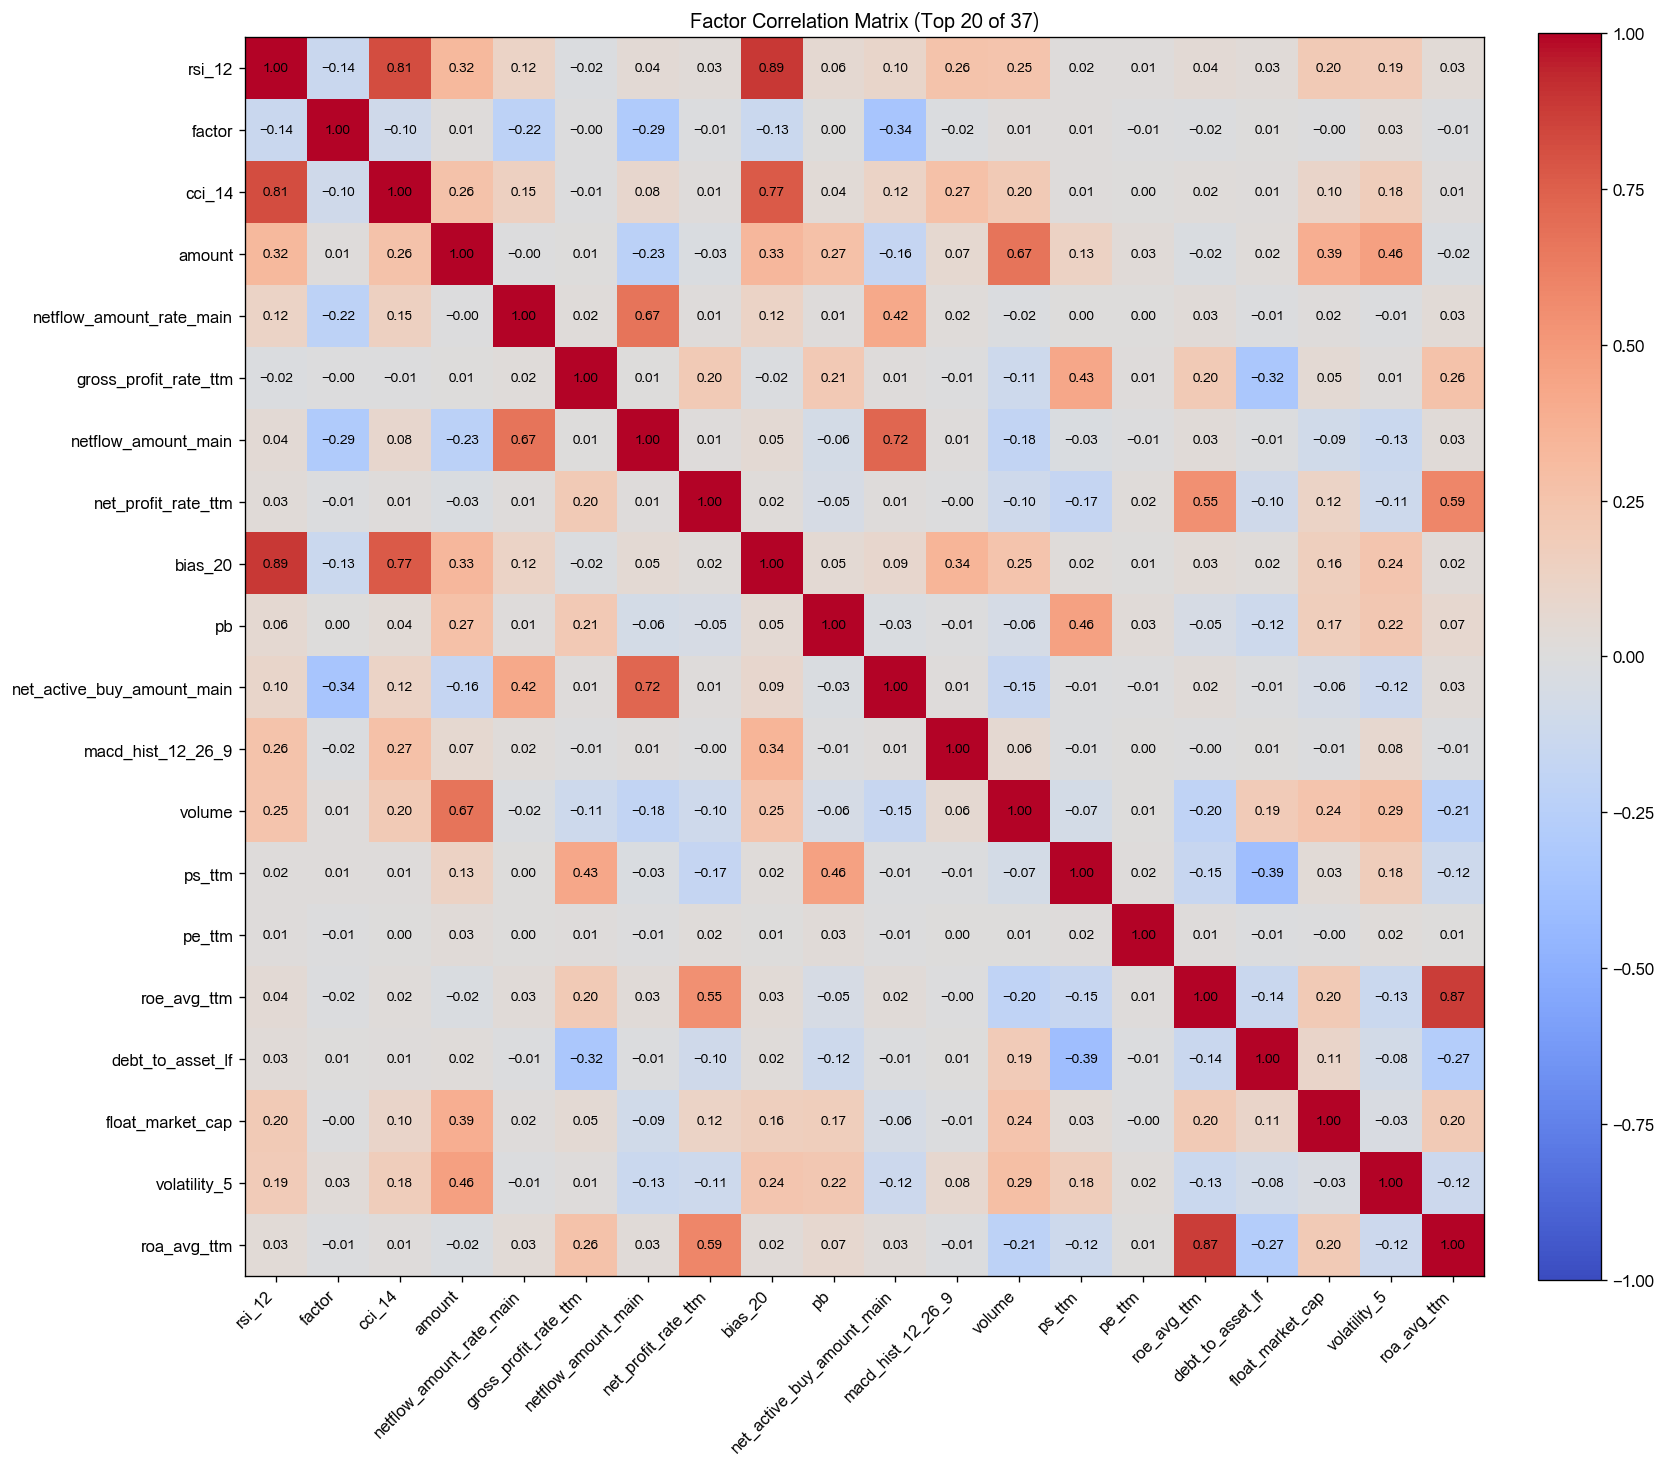

[2026-08-05 15:06:19] [warning  ] 返回的Outputs实例(size=35325164) 大于 64K, 将不会被缓存
[2026-08-05 15:06:19] [info     ] bigalpha_eval.v4 运行完成 [78.264s].


In [2]:
if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算 VWAP × 趋势强度联合因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
